<a href="https://colab.research.google.com/github/LlucCM/Practiques_Python/blob/main/LJfluid/metropolis_LJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MonteCarl (MC) simulation of a system of Lennard-Jones Spheres**

Simulation of a system of N atoms in a box of fixed dimensions (so fixed density) at a specified temeprature T.

Units: distance in Å and energy in kcal/mol

The Montecarlo  Metropolis simuation produces:
- A file with the positions of the atoms generated at the different MC steps
- The Energy along the simulation
- The number of accepted and rejected MC jumps


In [1]:
# Import libraries
import random
import math
import copy
import matplotlib.pyplot as plt

**Physical parameters of the simulation**

In [2]:
# Set the number of atoms in the box
n_atoms = 25

# Set the number of Monte Carlo moves to perform
num_moves = 5000

# Set the size of the box (in Angstroms)
box_size = [ 15.0, 15.0, 15.0 ]

# The maximum amount that the atom can be translated by
max_translate = 0.5    # angstroms

# Simulation temperature
temperature = 298.15   # kelvin

# Give the Lennard Jones parameters for the atoms
# (these are the OPLS parameters for Krypton)
sigma = 3.624         # angstroms
epsilon = 0.317       # kcal mol-1

**Simulation code**
Create data files and initial coordinates

In [3]:
# Create a data file to output coordinates
filename="trajectory.pdb"
FILE = open(filename, "w")
# Create a data file to output Energy and other data
FILE2= open("Energy.dat","w")

# Create an array to hold the coordinates of the atoms
coords = []

# Randomly generate the coordinates of the atoms in the box
for i in range(0,n_atoms):
    # Note "random.uniform(x,y)" would generate a random number
    # between x and y
    coords.append( [random.uniform(0,box_size[0]), \
                    random.uniform(0,box_size[1]), \
                    random.uniform(0,box_size[2]) ] )

Functions for the simulation

In [4]:
def make_periodic(x, box):
    """Subroutine to apply periodic boundaries"""
    while (x < -0.5*box):
        x += box

    while (x > 0.5*box):
        x -= box

    return x


def wrap_into_box(x, box):
    """Subroutine to wrap the coordinates into a box"""
    while (x > box):
        x -= box

    while (x < 0):
        x += box

    return x


def print_pdb(move):
	#Open file to add data
    FILE = open(filename, "a")

    #write simulation box data
    FILE.write("CRYST1 %8.3f %8.3f %8.3f  90.00  90.00  90.00\n" % \
                  (box_size[0], box_size[1], box_size[2]))

    #write atoms data
    for i in range(0,n_atoms):
        FILE.write("ATOM  %5d  Kr   Kr     1    %8.3f%8.3f%8.3f  1.00  0.00          Kr\n" % \
                      (i+1, coords[i][0], coords[i][1], coords[i][2]))
        #FILE.write("TER\n")

    #close file
    FILE.write("END\n")
    FILE.close()


# Subroutine that calculates the energies of the atoms
def calculate_energy():
    """Calculate the energy of the passed atoms (assuming all atoms
       have the same LJ sigma and epsilon values)"""

    # Loop over all pairs of atoms and calculate
    # the LJ energy
    total_energy = 0

    for i in range(0,n_atoms-1):
        for j in range(i+1, n_atoms):
            delta_x = coords[j][0] - coords[i][0]
            delta_y = coords[j][1] - coords[i][1]
            delta_z = coords[j][2] - coords[i][2]

            # Apply periodic boundaries
            delta_x = make_periodic(delta_x, box_size[0])
            delta_y = make_periodic(delta_y, box_size[1])
            delta_z = make_periodic(delta_z, box_size[2])

            # Calculate the distance between the atoms
            r = math.sqrt( (delta_x*delta_x) + (delta_y*delta_y) +
                           (delta_z*delta_z) )

            # E_LJ = 4*epsilon[ (sigma/r)^12 - (sigma/r)^6 ]
            e_lj = 4.0 * epsilon * ( (sigma/r)**12 - (sigma/r)**6 )

            total_energy += e_lj

    # return the total energy of the atoms
    return total_energy


**Main program for the calculation**

10 27473971027.10732  9  1
20 250449158.1198107  15  5
30 6546932.234684548  22  8
40 6407162.748994288  30  10
50 148269.33312535944  36  14
60 148151.13861139683  43  17
70 21429.555377160883  49  21
80 18150.149852256534  56  24
90 18144.43334272488  60  30
100 17763.986419851488  65  35
110 17621.3092508151  73  37
120 17619.208647192714  80  40
130 1762.7817453023154  87  43
140 235.2133439905959  96  44
150 93.37694226409832  103  47
160 92.41774585975747  106  54
170 44.35868691274416  112  58
180 33.18567221022256  119  61
190 10.465717873984811  125  65
200 9.04772893066117  134  66
210 9.308249929860446  141  69
220 4.778318431907563  145  75
230 2.9943584595489896  150  80
240 3.613548229049033  157  83
250 1.3165594485962488  164  86
260 2.0431645605639313  172  88
270 -2.3771806153820227  177  93
280 -2.4282321562267444  183  97
290 -3.686940417493231  188  102
300 -3.902801506152077  196  104
310 -11.05821095722646  203  107
320 -12.64756885177584  208  112
330 -14.637900

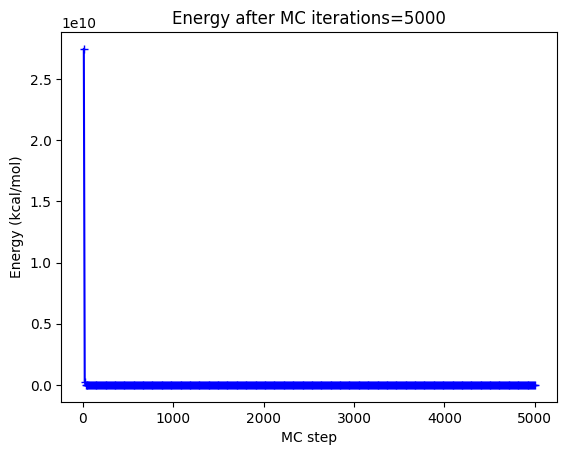

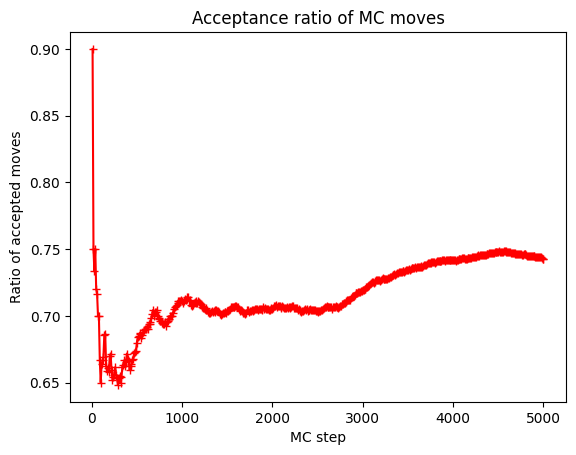

In [5]:
# calculate kT
k_boltz = 1.987206504191549E-003  # kcal mol-1 K-1

kT = k_boltz * temperature

# The total number of accepted moves
naccept = 0

# The total number of rejected moves
nreject = 0

#ratio accepted/total
ratio=[]

# Potential Energy
Epot_t=[]
t_step=[]

# Save the initial coordinates in PDB file
print_pdb(0)

# Now perform all of the moves
for move in range(1,num_moves+1):

    # calculate the old energy
    old_energy = calculate_energy()

    # Pick a random atom (random.randint(x,y) picks a random
    # integer between x and y, including x and y)
    atom = random.randint(0, n_atoms-1)

    # save the old coordinates
    old_coords = copy.deepcopy(coords)

    # Make the move - translate by a delta in each dimension
    delta_x = random.uniform( -max_translate, max_translate )
    delta_y = random.uniform( -max_translate, max_translate )
    delta_z = random.uniform( -max_translate, max_translate )

    coords[atom][0] += delta_x
    coords[atom][1] += delta_y
    coords[atom][2] += delta_z

    # wrap the coordinates back into the box
    coords[atom][0] = wrap_into_box(coords[atom][0], box_size[0])
    coords[atom][1] = wrap_into_box(coords[atom][1], box_size[1])
    coords[atom][2] = wrap_into_box(coords[atom][2], box_size[2])

    # calculate the new energy
    new_energy = calculate_energy()

    accept = False

    # Automatically accept if the energy goes down
    if (new_energy <= old_energy):
        accept = True

    else:
        # Now apply the Monte Carlo test - compare
        # exp( -(E_new - E_old) / kT ) >= rand(0,1)
        x = math.exp( -(new_energy - old_energy) / kT )

        if (x >= random.uniform(0.0,1.0)):
            accept = True
        else:
            accept = False

    if accept:
        # accept the move
        naccept += 1
        total_energy = new_energy
    else:
        # reject the move - restore the old coordinates
        nreject += 1

        # restore the old conformation
        coords = copy.deepcopy(old_coords)

        total_energy = old_energy

    # print the energy every 10 moves
    if move % 10 == 0:
        print("%s %s  %s  %s" % (move, total_energy, naccept, nreject))
        FILE2.write("%s %s  %s  %s \n" % (move, total_energy, naccept, nreject))

        #accumulate data
        ratio.append(float(naccept)/float(naccept+nreject))
        Epot_t.append(total_energy)
        t_step.append(move)

    # print the coordinates every 100 moves
    if move % 100 == 0:
        print_pdb(move)

#End of calculation
FILE2.close()
#interactive plotting off
#Plot evolution of Energy
plt.title('Energy after MC iterations=%d'%move);
plt.ylabel('Energy (kcal/mol)')
plt.plot(t_step, Epot_t, 'b+-')
plt.xlabel('MC step')
plt.show()

#Plot evolution of accepted/rejected trials
plt.title('Acceptance ratio of MC moves');
plt.ylabel('Ratio of accepted moves')
plt.xlabel('MC step')
plt.plot(t_step, ratio, 'r+-')
plt.show()